In [1]:
from synaptic_tomo_tools.activezone import import_membrane_segmentations, find_active_zones, import_membrane_segmentations_from_glb, find_active_zones_from_glb, define_active_zone
from synaptic_tomo_tools.visualization import load_tomogram_slice, filter_coords_in_slice

# Calculate active zones from points

In [2]:
tomo_path = "/nrs/elferich/20241030_AMmilled12-1_15"
membranes = import_membrane_segmentations("/nrs/elferich/20241030_AMmilled12-1_15")

Found 1 presynaptic membrane files
Found 1 postsynaptic membrane files
Presynaptic membrane 1 volume: 0.032700 µm³ (576301 points)
Postsynaptic membrane 1 volume: 0.030143 µm³ (721748 points)


In [3]:
active_zones = find_active_zones(membranes)

Found active zone: active_zone_pre1_post1 with 217453 presynaptic and 201634 postsynaptic points


# Calculate active zones from mesh

In [4]:
membranes_glb = import_membrane_segmentations_from_glb(tomo_path)

In [5]:
active_zones_glb = find_active_zones_from_glb(membranes_glb)

Found active zone: active_zone_pre1_post1 with 111280 presynaptic and 101361 postsynaptic points


# Visualize active zone from points

In [8]:
from synaptic_tomo_tools.visualization import load_tomogram_slice, filter_coords_in_slice
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

In [9]:
z_center = int(np.mean(active_zones['active_zones']['active_zone_pre1_post1']['active_presynaptic_points'][:,2])) 
print(f"Using z_center: {z_center}")
slice2d, zc = load_tomogram_slice(tomo_path, z_center)
vmin, vmax = np.percentile(slice2d, [2, 98])

Using z_center: 148


Text(0, 0.5, 'Y (pixels)')

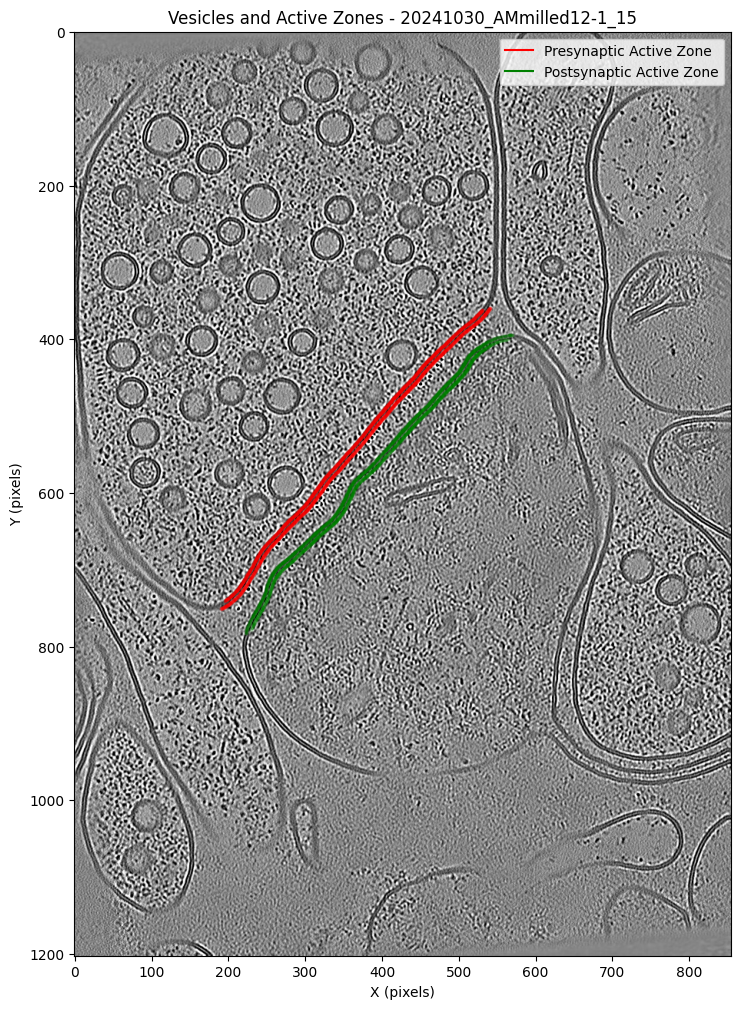

In [10]:
tomo_name = Path(tomo_path).name
    
# Version X: Active Zones

fig1, ax1 = plt.subplots(figsize=(12, 12))
ax1.imshow(slice2d, cmap='gray', vmin=vmin, vmax=vmax)
z_thresh_az = 1
azs_pre_in_slice = filter_coords_in_slice([active_zones['active_zones']['active_zone_pre1_post1']['active_presynaptic_points']], z_center, z_thresh_az, None)
azs_post_in_slice = filter_coords_in_slice([active_zones['active_zones']['active_zone_pre1_post1']['active_postsynaptic_points']], z_center, z_thresh_az, None)
# Overlay presynaptic active zone with transparent red
coords = azs_pre_in_slice[0]
ax1.scatter(coords[:,0], coords[:,1], color='red', s=3, alpha=0.1, 
        label='Presynaptic Active Zone' if 'Presynaptic Active Zone' not in [l.get_label() for l in ax1.get_legend_handles_labels()[0]] else '')

# Overlay postsynaptic active zone with transparent green
coords = azs_post_in_slice[0]
ax1.scatter(coords[:,0], coords[:,1], color='green', s=3, alpha=0.1, 
        label='Postsynaptic Active Zone' if 'Postsynaptic Active Zone' not in [l.get_label() for l in ax1.get_legend_handles_labels()[0]] else '')

# Add note about distance filtering to legend
legend_elements = [
    Line2D([0], [0], color='red', lw=1.5, label='Presynaptic Active Zone'),
    Line2D([0], [0], color='green', lw=1.5, label='Postsynaptic Active Zone')
]
ax1.legend(handles=legend_elements)
ax1.set_title(f'Vesicles and Active Zones - {tomo_name}')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')

# Visualize active zone from mesh

Text(0, 0.5, 'Y (pixels)')

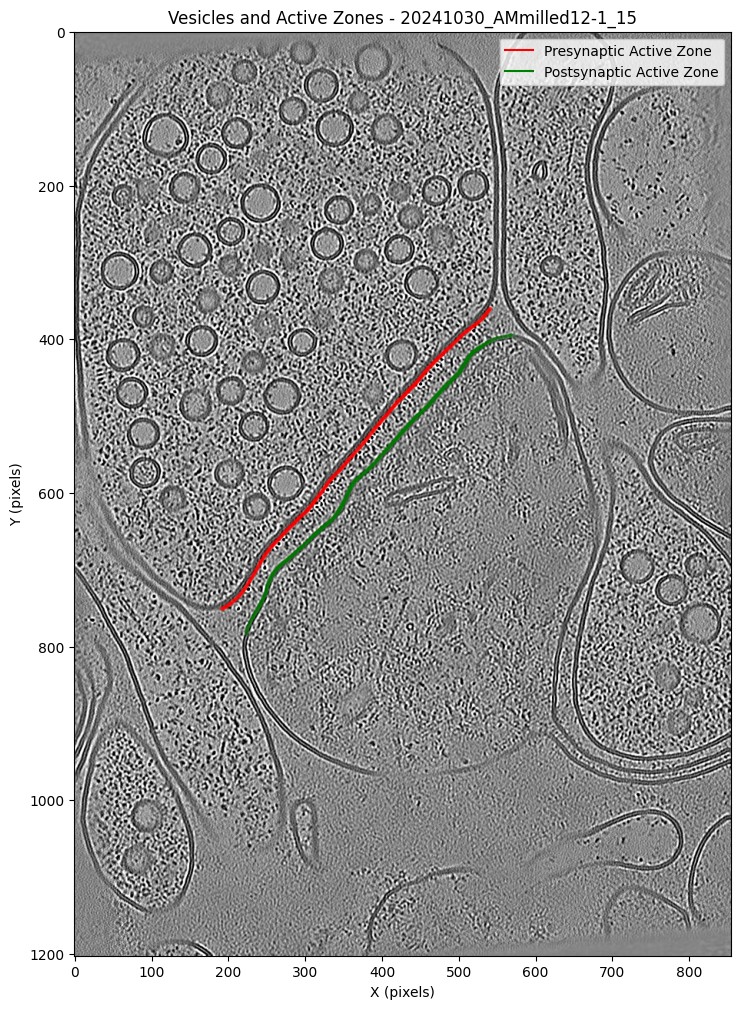

In [11]:
tomo_name = Path(tomo_path).name
    
# Version X: Active Zones

fig1, ax1 = plt.subplots(figsize=(12, 12))
ax1.imshow(slice2d, cmap='gray', vmin=vmin, vmax=vmax)
z_thresh_az = 1
azs_pre_in_slice = filter_coords_in_slice([active_zones_glb['active_zones']['active_zone_pre1_post1']['active_presynaptic_points']], z_center, z_thresh_az, None)
azs_post_in_slice = filter_coords_in_slice([active_zones_glb['active_zones']['active_zone_pre1_post1']['active_postsynaptic_points']], z_center, z_thresh_az, None)
# Overlay presynaptic active zone with transparent red
coords = azs_pre_in_slice[0]
ax1.scatter(coords[:,0], coords[:,1], color='red', s=3, alpha=0.1, 
        label='Presynaptic Active Zone' if 'Presynaptic Active Zone' not in [l.get_label() for l in ax1.get_legend_handles_labels()[0]] else '')

# Overlay postsynaptic active zone with transparent green
coords = azs_post_in_slice[0]
ax1.scatter(coords[:,0], coords[:,1], color='green', s=3, alpha=0.1, 
        label='Postsynaptic Active Zone' if 'Postsynaptic Active Zone' not in [l.get_label() for l in ax1.get_legend_handles_labels()[0]] else '')

# Add note about distance filtering to legend
legend_elements = [
    Line2D([0], [0], color='red', lw=1.5, label='Presynaptic Active Zone'),
    Line2D([0], [0], color='green', lw=1.5, label='Postsynaptic Active Zone')
]
ax1.legend(handles=legend_elements)
ax1.set_title(f'Vesicles and Active Zones - {tomo_name}')
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')

# Compare Measurements

In [17]:
res = define_active_zone(tomo_path)
avg_distance = active_zones['active_zones']['active_zone_pre1_post1']['avg_distance']
presynaptic_area = res['avg_active_zone_area']

Defining active zone in 20241030_AMmilled12-1_15
Found 1 presynaptic membrane files
Found 1 postsynaptic membrane files
Presynaptic membrane 1 volume: 0.032700 µm³ (576301 points)
Postsynaptic membrane 1 volume: 0.030143 µm³ (721748 points)
Found active zone: active_zone_pre1_post1 with 217453 presynaptic and 201634 postsynaptic points
Active zone area active_zone_pre1_post1: 0.074273 µm²
Average presynaptic membrane volume: 0.032700 µm³ (1 membranes)
Average postsynaptic membrane volume: 0.030143 µm³ (1 membranes)


In [18]:
avg_distance_glb = active_zones_glb['active_zones']['active_zone_pre1_post1']['avg_distance']
presynaptic_area_glb = active_zones_glb['active_zones']['active_zone_pre1_post1']['active_presynaptic_area']

In [23]:
print(f"Average distance between presynaptic and postsynaptic points: {avg_distance:.1f} nm")
print(f"Average presynaptic area: {presynaptic_area:.3f} µm²")
print(f"Average distance between presynaptic and postsynaptic points (GLB): {avg_distance_glb:.1f} nm")
print(f"Average presynaptic area (GLB): {presynaptic_area_glb:.3f} µm²")

Average distance between presynaptic and postsynaptic points: 28.5 nm
Average presynaptic area: 0.074 µm²
Average distance between presynaptic and postsynaptic points (GLB): 26.2 nm
Average presynaptic area (GLB): 0.065 µm²
